In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**2. Loading and Exploring the Iris Dataset**

In [2]:
# Load the dataset
iris = sns.load_dataset("iris")

# Display basic information
print(iris.head())
print(iris.info())
print(iris.describe())

# Check for missing values
print(iris.isnull().sum())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000   

*   The Iris dataset contains measurements of sepal length, sepal width, petal length, and petal width for three species of Iris flowers: setosa, versicolor, and virginica.
*   There are no missing values.

**3. Exploratory Data Analysis (EDA)**

*   **Pairplot:** Visualize relationships between pairs of features, colored by species.

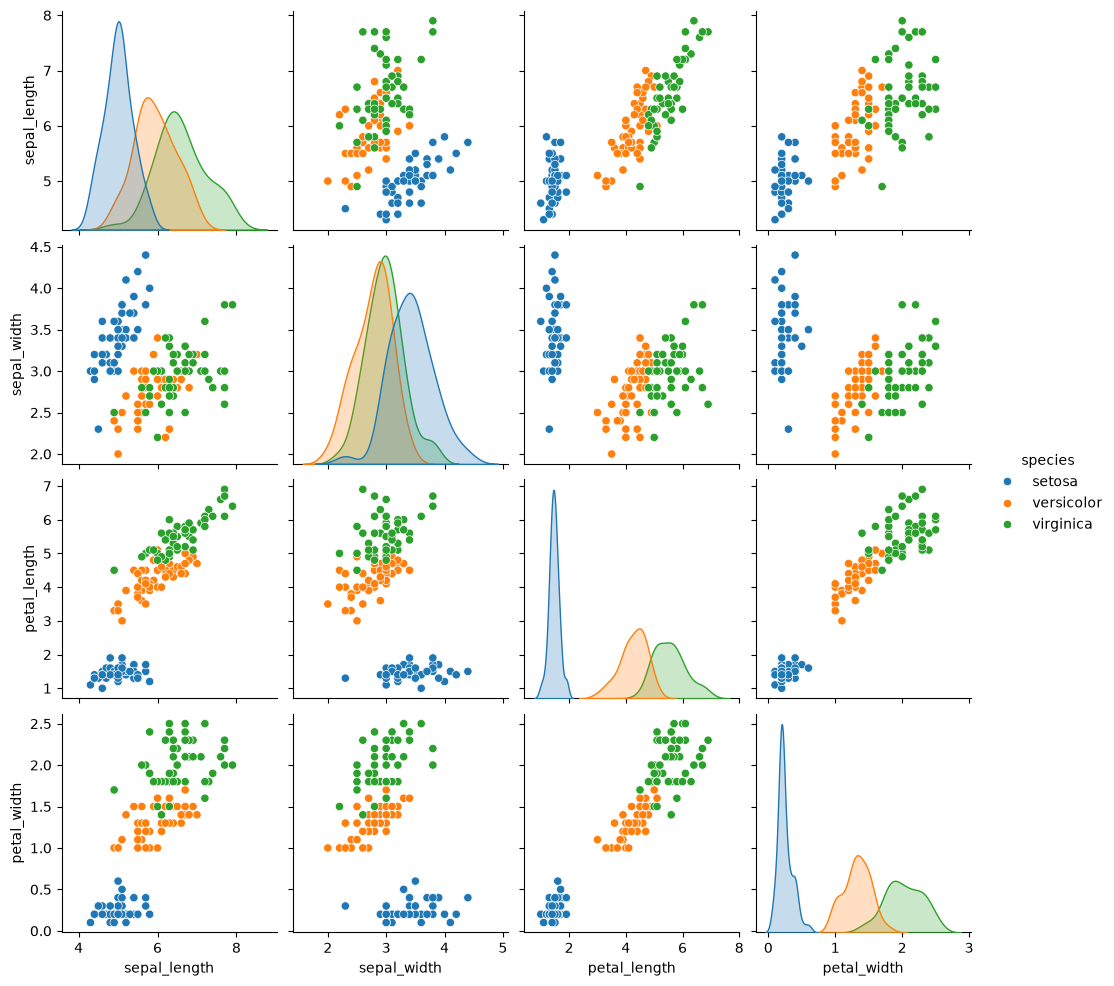

In [3]:
sns.pairplot(iris, hue="species")
plt.show()

*   **Boxplots:** Examine the distribution of each feature for each species.

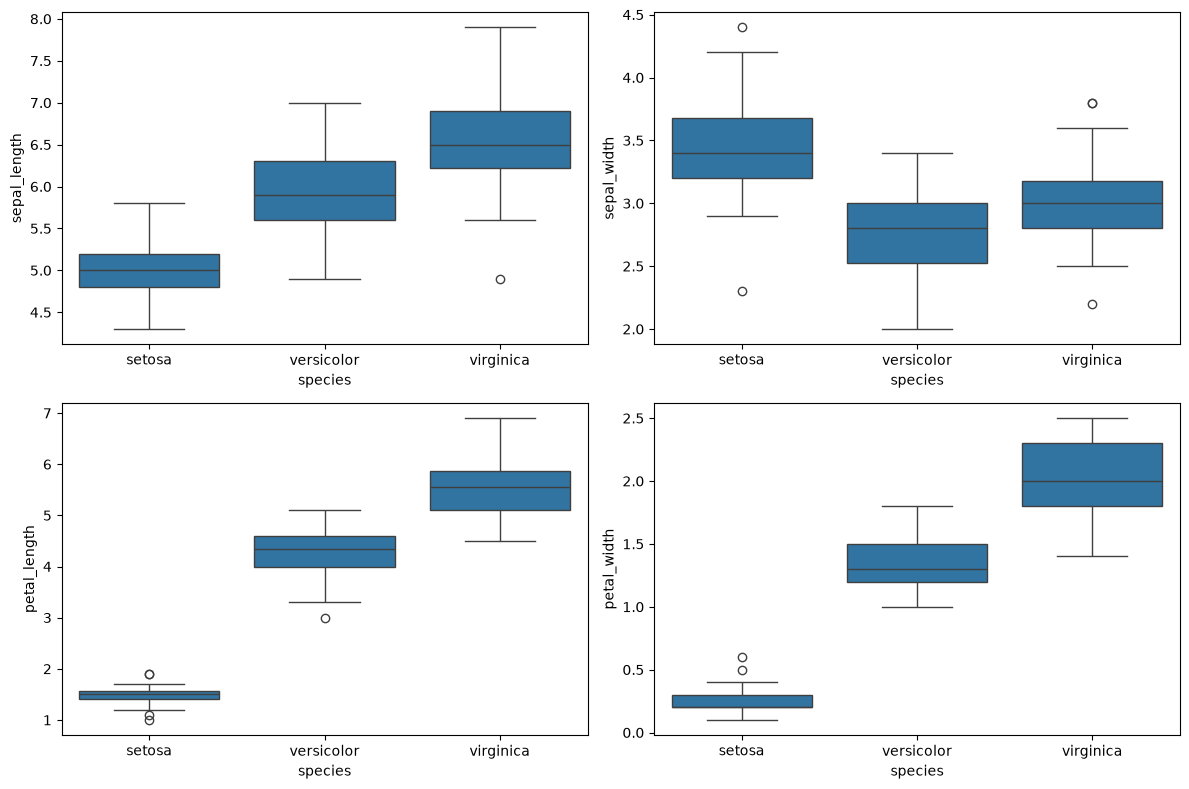

In [4]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.columns[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x="species", y=feature, data=iris)
plt.tight_layout()
plt.show()

*   **Histograms:** Explore the distribution of each feature.

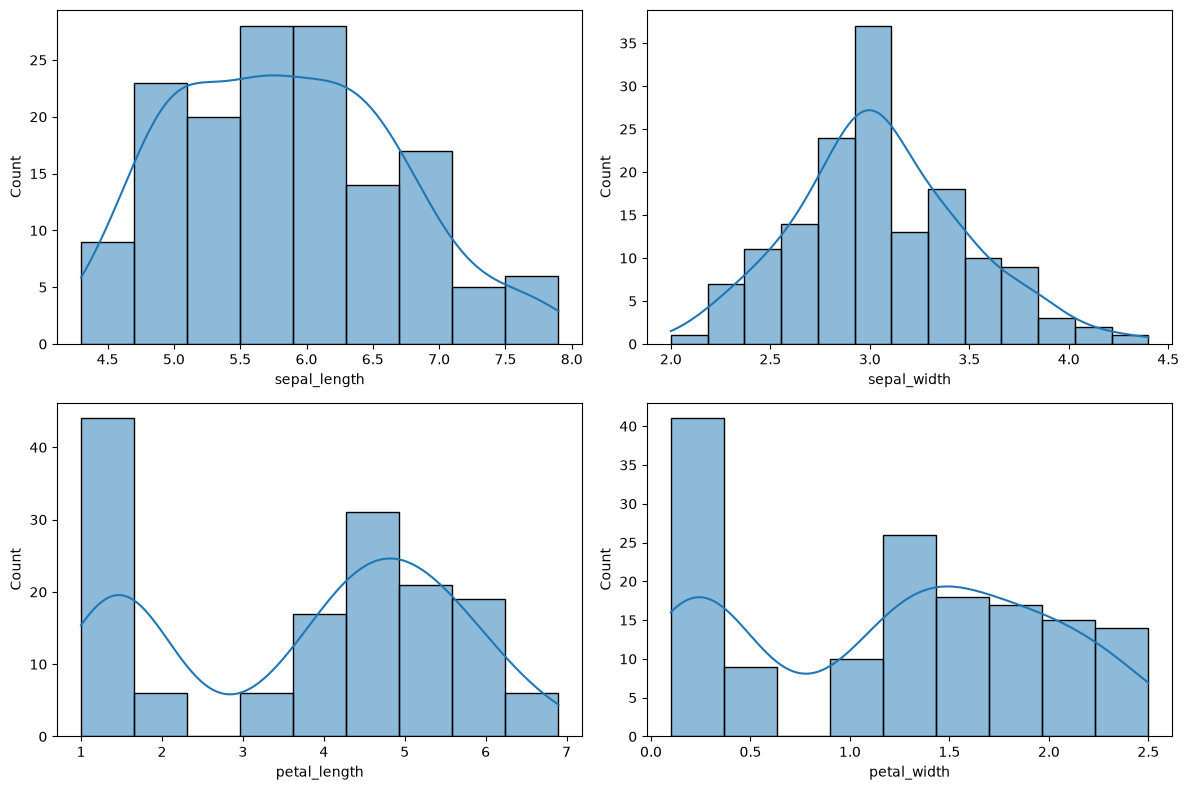

In [5]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.columns[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(iris[feature], kde=True)
plt.tight_layout()
plt.show()

**Observations from EDA:**

*   Setosa generally has smaller petal lengths and widths compared to the other species.
*   Versicolor and virginica are less distinctly separated, especially based on sepal length and width.
*   Petal length and width seem to be good indicators for distinguishing between the species.

**4. Data Preprocessing**

In [6]:
# Separate features (X) and target (y)
X = iris.drop("species", axis=1)
y = iris["species"]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

*   We standardize the features to have zero mean and unit variance. This often helps improve the performance of GMM.

**5. Splitting Data into Training and Testing Sets**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

*   We split the data into 70% for training and 30% for testing.

**6. Implementing Gaussian Mixture Model**

In [8]:
# Initialize and train the GMM
gmm = GaussianMixture(n_components=3, random_state=42)  # We know there are 3 species
gmm.fit(X_train)

# Predict on the test set
y_pred = gmm.predict(X_test)

y_pred

array([2, 1, 0, 2, 2, 1, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 0, 2, 2, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 0, 2, 2, 1,
       1])

In [9]:
# Assign cluster labels based on majority vote per cluster
cluster_labels = {}
for cluster in range(3):
    true_labels = y_train.iloc[np.where(gmm.predict(X_train) == cluster)]
    majority_label = true_labels.mode()[0]
    cluster_labels[cluster] = majority_label

# Map cluster indices to predicted species labels
y_pred_species = [cluster_labels[cluster] for cluster in y_pred]
y_pred_species

['versicolor',
 'setosa',
 'virginica',
 'versicolor',
 'versicolor',
 'setosa',
 'versicolor',
 'virginica',
 'virginica',
 'versicolor',
 'virginica',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'versicolor',
 'virginica',
 'versicolor',
 'versicolor',
 'virginica',
 'setosa',
 'virginica',
 'setosa',
 'virginica',
 'virginica',
 'virginica',
 'virginica',
 'virginica',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'versicolor',
 'setosa',
 'setosa',
 'virginica',
 'versicolor',
 'setosa',
 'setosa',
 'setosa',
 'virginica',
 'versicolor',
 'versicolor',
 'setosa',
 'setosa']

*   We initialize the GMM with `n_components=3` because we know there are three Iris species.
*   We fit the GMM on the training data.
*   We predict the cluster assignments for the test data using `gmm.predict()`.
*   Since GMM doesn't output species labels, we need to map the cluster indices to species names. This is done by a majority vote of true labels in each cluster.

**7. Evaluating the Model**

In [10]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_species)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9778


**Complete Code**

**Results**

The accuracy and classification report will show the performance of the GMM. You should observe a relatively high accuracy (likely above 90%), indicating that the GMM is able to cluster the Iris data effectively. The classification report will provide precision, recall, F1-score, and support for each species.

**Important Considerations**

*   **Determining the Number of Components:** In this case, we knew the number of species (3). In real-world scenarios, you might need to use techniques like the Bayesian Information Criterion (BIC) or the silhouette score to find the optimal number of clusters.
*   **Initialization:** GMM can be sensitive to initialization. Using `random_state` helps with reproducibility, but you might also want to explore different initialization methods (e.g., `kmeans`, `random_from_data`).
*   **Mapping Clusters to Labels:** Remember that the GMM itself doesn't assign meaningful labels. The majority voting approach used here is a common way to map clusters to known classes if you have some labeled data available.

This comprehensive example demonstrates how to implement GMM on a real dataset, including EDA, preprocessing, model training, and evaluation. Remember to adapt the code and techniques based on the specific characteristics of your dataset and problem.